# Aims-vcr


Zero-shot Visual Commonsense Reasoning with Qwen2.5-VL-3B-Instruct: a two-stage pipeline that (1) picks the best-supported answer to a question about an image, then (2) picks the rationale that best explains that answer, over 50 streamed VCR samples.

## Setup

In [1]:
# Install the libraries needed to run Qwen2.5-VL: a dev build of transformers
# (for the newest Qwen2.5-VL model classes), accelerate (device placement),
# qwen-vl-utils (VL-specific helpers), and bitsandbytes (4-bit quantization).
!pip install -q git+https://github.com/huggingface/transformers accelerate qwen-vl-utils bitsandbytes

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 17.8 MB/s eta 0:00:00


In [2]:
# Sanity check: confirm PyTorch can see a GPU before loading a multi-billion-parameter model.
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## Load the model

The model I am loading is in 4 bit quantization
This is because of the VRAM limitations of the T4 GPU

Although model loads in 6-7 Gigs (RAM+VRAM) (slang for GigaByte btw), the main problem is when you ask it questions

The VRAM consumption can spike to 12-13 Gigs.

In [ ]:
# Load Qwen2.5-VL-3B-Instruct in 4-bit precision (fits on a single GPU) plus its processor. 
# I was using T4 GPU, since it has like 16GB VRAM, this fits

import torch
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

model_name = "Qwen/Qwen2.5-VL-3B-Instruct"


# 4-bit quantization shrinks the model's memory footprint; compute still happens in float16.
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
)

# device_map="auto" lets HF place the model's layers on whatever device(s) are available (the GPU, if present).
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    quantization_config=quantization_config,
    device_map="auto",
)

# The processor is the multimodal counterpart of a tokenizer: it turns text + images into model-ready tensors.
processor = AutoProcessor.from_pretrained(model_name)

print("Model loaded!")

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Model loaded!


In [ ]:
#HIDDEN CODE: ACTIVATES QWEN3VL 4B model shhhhhhhhh, BUT YOU HAVE TO UNCOMMENT IT OBV
#This takes roughly 8-9 Gigs (RAM+VRAM)
#Answer generation also roughly takes 8 times the time, felt like 3 business days

# import torch
# from transformers import Qwen3VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

# model_name = "Qwen/Qwen3-VL-4B-Instruct"


# quantization_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_compute_dtype=torch.float16,
# )

# model = Qwen3VLForConditionalGeneration.from_pretrained(
#     model_name,
#     quantization_config=quantization_config,
#     device_map="auto",
# )

# processor = AutoProcessor.from_pretrained(model_name)

# print("Model loaded!")

## Shared state
Imports and module-level variables the functions below read and write.

In [4]:
# Image: PIL's core class, used below to load/resize/display the sample image.
# requests + BytesIO: the usual pair for pulling an image from a URL straight into
# memory (Image.open(BytesIO(requests.get(url).content))) if a sample ever needs to
# be fetched by link instead of coming from the cached dataset image.
from PIL import Image
import requests
from io import BytesIO

In [33]:
# Running totals & shared state, updated inside output_generator() (cell 15) and read at the end of the main loop (cell 16).
correct_answers = 0
# count of Stage 1 predictions that matched the ground-truth answer letter
correct_rationales = 0
# count of Stage 2 predictions that matched the ground-truth rationale letter
output = []
# holds the model's most recent decoded reply; output_generator() overwrites this every call, and rPrompt() reads it back
predicted_answer = ""
# holds Stage 1's predicted letter (e.g. "A"), set inside rPrompt()


## Load the VCR dataset

I am using the rowan/vcr dataset available on huggingface

It's 32 Gigs (slang for Gigabyte :P)
And since, I'm using like 50-100 images at the moment, Ill just keep streamin = True

One thing that i'd like to mention is that, the questions and images live seperately in the dataset (obviously)
So there can be multiple questions pointing to the same question.

Like basically, 
Image 1 has Question 1, Question 2 and Question 3
Image 2 has Q4, Q5, Q6, Q7
Image 3 has Q8
Image 4 had Q9, Q10, etc

So over these 10 questions, i only had 4 unique images

In [6]:
# Stream the VCR question/answer/rationale annotations from Hugging Face.
from datasets import load_dataset

# streaming=True fetches samples one at a time instead of downloading the whole
# dataset up front. The "questions" config is the text side of VCR: question,
# 4 answer choices, 4 rationale choices, and the correct-answer/rationale indices
# (no images here — those live in a separate image config, see cell 10).
dataset = load_dataset(
    "Rowan/vcr",
    name="questions",
    split="train",
    streaming=True
)

README.md:   0%|          | 0.00/1.80k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

In [52]:
# Pull 50 samples out of the stream into a plain Python list so they can be indexed/reused freely.
# a manual iterator so next() can be called repeatedly below
question_iter = iter(dataset)

samples = []

# next(question_iter) fetches one fresh sample from the stream per call
for _ in range(50):
    samples.append(next(question_iter))

print(len(samples))

50


## Cache the needed images

As I mentioned, multiple questions can map to the samae image, hence caching becomes imp.

In [53]:
# Several questions can point at the same image, so collect the *unique* filenames
# this batch of 50 samples references — that's exactly which images need fetching next.
needed_images = set(sample["img_fn"] for sample in samples)

print(len(needed_images))

17


In [ ]:
#This is the image loading part, no I'm not using the same command twice
#This has a different tag, "image_examples"


from datasets import load_dataset

def load_images(split="train"):
    return load_dataset(
        "Rowan/vcr",
        "image_examples",
        split=split,
        streaming=True,
    )
image_dataset = load_images("train")

In [ ]:
# Build a lookup dict {img_fn: PIL image}, keeping only the images this batch needs, and stop early once they're all found.
image_cache = {}

for img_sample in image_dataset:
    img_fn = img_sample["img_fn"]

    if img_fn in needed_images:
        image_cache[img_fn] = img_sample["image"]

        print("Loaded:", img_fn)

    if len(image_cache) == len(needed_images):
        break

Loaded: lsmdc_3015_CHARLIE_ST_CLOUD/3015_CHARLIE_ST_CLOUD_00.23.57.935-00.24.00.783@0.jpg
Loaded: lsmdc_3038_ITS_COMPLICATED/3038_ITS_COMPLICATED_00.08.14.616-00.08.17.313@0.jpg
Loaded: lsmdc_1051_Harry_Potter_and_the_goblet_of_fire/1051_Harry_Potter_and_the_goblet_of_fire_02.10.26.133-02.10.30.224@0.jpg
Loaded: lsmdc_1051_Harry_Potter_and_the_goblet_of_fire/1051_Harry_Potter_and_the_goblet_of_fire_02.21.22.023-02.21.30.292@2.jpg
Loaded: lsmdc_1051_Harry_Potter_and_the_goblet_of_fire/1051_Harry_Potter_and_the_goblet_of_fire_02.14.47.022-02.14.53.458@1.jpg
Loaded: lsmdc_3057_ROBIN_HOOD/3057_ROBIN_HOOD_01.20.03.466-01.20.05.593@0.jpg
Loaded: lsmdc_3050_MR_POPPERS_PENGUINS/3050_MR_POPPERS_PENGUINS_01.11.14.821-01.11.20.823@2.jpg
Loaded: lsmdc_0009_Forrest_Gump/0009_Forrest_Gump_01.42.17.758-01.42.22.684@1.jpg
Loaded: lsmdc_3038_ITS_COMPLICATED/3038_ITS_COMPLICATED_00.24.04.696-00.24.09.983@1.jpg
Loaded: lsmdc_3038_ITS_COMPLICATED/3038_ITS_COMPLICATED_01.49.34.202-01.49.39.863@2.jpg
Loaded

## Try the pipeline on one sample

(1920, 799)
(768, 320)


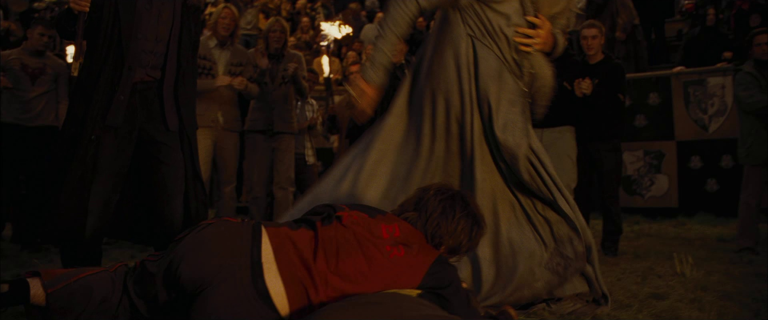

In [ ]:
# Load cached image, shrink it for faster processing
for sample in samples:
  image_cache[sample["img_fn"]].thumbnail((768, 768))

# thumbnail() resizes in place (keeping aspect ratio) so the longest side is at most 768px

In [ ]:
#Testing on a random sample to sanity check this
sample = samples[8]

image = image_cache[sample["img_fn"]]

print(type(image))
print(image.mode)
print(image.size)

## Prompt builders
Two functions that format a VCR sample into the text prompt for each stage.

In [58]:
def aPrompt(sample):
  """Build the Stage 1 prompt: ask the model to pick the answer (A-D) best
  supported by this VCR sample's image and question text."""

  question = sample["question_text"]
  answers = sample["answer_choice_texts"]

  # multi-line f-string template — {question} and {answers[i]} are interpolated directly into the instruction text
  prompt = f"""
  You are solving a Visual Commonsense Reasoning (VCR) multiple-choice question.

  Question:
  {question}

  Answer choices:

  A. {answers[0]}
  B. {answers[1]}
  C. {answers[2]}
  D. {answers[3]}

  Select the answer that is best supported by the image and question.

  Respond with ONLY one letter: A, B, C, or D.
  """
  return prompt
  # print(prompt)

In [69]:
def rPrompt(sample):
  """Build the Stage 2 prompt: ask the model to pick the rationale (A-D) that
  best explains the answer predicted by the most recent output_generator() call.
  Reads the Stage 1 result from the module-level `output` list rather than
  taking it as a function argument."""
  global output
  global predicted_answer

  # `output` was last set by output_generator() when Stage 1 ran; output[0] is the
  # model's raw one-letter reply (e.g. "A") — so predicted_answer is that letter,
  # not the text of the answer choice itself.
  predicted_answer = output[0].strip()
  question = sample["question_text"]
  rationales = sample["rationale_choice_texts"]

  rationale_prompt = f"""
  You are solving the rationale-selection stage of a Visual Commonsense Reasoning (VCR) task.

  Question:
  {question}

  The selected answer is:
  {predicted_answer}

  Choose the rationale that best explains why the selected answer is correct.

  Rationale choices:

  A. {rationales[0]}
  B. {rationales[1]}
  C. {rationales[2]}
  D. {rationales[3]}

  Respond with ONLY one letter: A, B, C, or D.
  """
  return rationale_prompt
  # print(rationale_prompt)

## Run inference
The function that actually calls the model and scores its reply.

In [70]:
def output_generator(prompt, answer_or_rationale):
  """Run one generation pass: send `image` + `prompt` to the model, decode a
  single-letter reply, print it next to the ground-truth letter, and tally it
  into correct_answers or correct_rationales.

  answer_or_rationale: True means this call is scoring the Stage 1 answer prompt
  (cell 13); False means it's scoring the Stage 2 rationale prompt (cell 14).
  """
  global output
  global predicted_answer
  global correct_answers
  global correct_rationales
  # reads/writes shared state (set up in cell 6) instead of taking it as parameters or a return value

  # Qwen2.5-VL's expected chat format: one user turn holding an image block and a text block
  messages = [
      {
          "role": "user",
          "content": [
              {
                  "type": "image",
                  "image": image,
              },
              {
                  "type": "text",
                  "text": prompt,
              },
          ],
      }
  ]

  # turn the structured `messages` into the exact prompt string the model was trained on,
  # adding the special tokens that tell it "now it's your turn to reply" (add_generation_prompt=True)
  text = processor.apply_chat_template(
      messages,
      tokenize=False,
      add_generation_prompt=True
  )

  # tokenize the text and preprocess the image together into model-ready tensors, then move them to the model's device
  inputs = processor(
      text=[text],
      images=[image],
      padding=True,
      return_tensors="pt",
  ).to(model.device)

  # only 1 new token is generated since the whole reply is a single letter (A-D)
  generated_ids = model.generate(
      **inputs,
      max_new_tokens=1, #Limits to one token
      do_sample = False #This ppicks the highest probability token, instead of being creative, is this temperature 0?
  # yes — do_sample=False is greedy decoding, which is mathematically the same as sampling at temperature -> 0: always take the argmax token
  )



  # model.generate() returns the prompt tokens *and* the new token concatenated together,
  # so record how many tokens were prompt...
  input_length = inputs["input_ids"].shape[1]
  # ...and slice those off, keeping only the newly generated token(s)
  generated_ids = generated_ids[:, input_length:]

  # convert the generated token id(s) back into a plain string (skip_special_tokens drops things like the EOS token)
  output = processor.batch_decode(
      generated_ids,
      skip_special_tokens=True
  )

  # --- Stage 1 (answer) branch ---
  if answer_or_rationale:
    print("Model:", output[0])
    # sample["answer_label"] is the correct choice's index (0-3); "ABCD"[index] turns it back into a letter
    print("Correct:", "ABCD"[sample["answer_label"]])
    if output[0].strip() == "ABCD"[sample["answer_label"]]:
      correct_answers += 1

  # --- Stage 2 (rationale) branch, mirrors the block above using rationale_label ---
  elif not answer_or_rationale:
    print("Model rationale:", output[0])
    print("Correct rationale:", "ABCD"[sample["rationale_label"]])

    if output[0].strip() == "ABCD"[sample["rationale_label"]]:
      correct_rationales += 1




## Evaluate all samples

In [73]:
# Run both stages over all 50 samples, tallying correct_answers / correct_rationales as we go.
for sample in samples:
  # Stage 1: build the answer prompt and generate a prediction
  prompt_a = aPrompt(sample)
  output_generator(prompt_a,True)
  # Stage 2: build the rationale prompt (reads Stage 1's predicted letter) and generate a prediction
  prompt_r = rPrompt(sample)
  output_generator(prompt_r,False)

# raw counts out of len(samples) — e.g. correct_answers / len(samples) gives an accuracy percentage
print(correct_answers)
print(correct_rationales)



Model: B
Correct: B
Model rationale: B
Correct rationale: B
Model: A
Correct: C
Model rationale: D
Correct rationale: C
Model: A
Correct: C
Model rationale: B
Correct rationale: B
Model: A
Correct: D
Model rationale: C
Correct rationale: A
Model: B
Correct: C
Model rationale: B
Correct rationale: B
Model: A
Correct: D
Model rationale: A
Correct rationale: C
Model: B
Correct: B
Model rationale: B
Correct rationale: D
Model: B
Correct: B
Model rationale: B
Correct rationale: D
Model: A
Correct: C
Model rationale: A
Correct rationale: A
Model: D
Correct: C
Model rationale: B
Correct rationale: B
Model: B
Correct: D
Model rationale: C
Correct rationale: C
Model: A
Correct: A
Model rationale: A
Correct rationale: B
Model: B
Correct: C
Model rationale: A
Correct rationale: D
Model: C
Correct: A
Model rationale: C
Correct rationale: C
Model: A
Correct: D
Model rationale: A
Correct rationale: D
Model: B
Correct: C
Model rationale: B
Correct rationale: D
Model: A
Correct: D
Model rationale: B
C

## Hey you made it to the end

So the model scored 13/50 on the Q -> A

16/50 on the QA -> R

AND a whopping 3/50 on Q -> AR

(These are average scores, on multiple epochs)

Scores Right Now:

### Qwen 2.5 3B Instruct 4-bit
| Metrics | Accuracy |
|---------|----------|
| Q -> A | 26% |
| QA -> R | 32% |
| Q -> AR | 6% |

I dont think this qwen2.5 3B will help me get into AIMS tho T-T

P.S. : I made this table myself in .md. Will make it in a super cool bar graph later


# Update 13th Aug
I added Qwen 3 4B to the mix

Pros: Newer model, More Params
Cons: Took 5 business days, minor improvevment in scores

### Qwen 3 4B Instruct 4-bit
| Metrics | Accuracy | Improvement |
|---------|----------|-------------|
| Q -> A | 32% | 23.1% |
| QA -> R | 36% | 12.5% |
| Q -> AR | 10% | 66.7% |

This also wouldnt be enough to guarantee my entry in AIMS
Now what do I do, hmmm

## What next then?
I could try newer models, but how annoying would that be.
I already have a 16GB VRAM limit, so 1 of 2 things can happen

Either I take a larger model with 4 bit quantization,
Or I take a smaller model with idk, 8 bit quantization

So the first step makes more sense to me
But before moving forward, there is one last thing I'd check

That is improving my prompt.
Right now, the prompt is kinda shit, maybe improving that helps?

### What do you think would happen, if the prompt improved?
Frankly I have low hopes from this. Prompting can only take you to a certain level, hence I will definitely try it out



In [ ]:
def rPrompt(sample):
  global output
  global predicted_answer

  predicted_answer = output[0].strip()
  question = sample["question_text"]
  rationales = sample["rationale_choice_texts"]

  rationale_prompt = f"""
You are solving the rationale-selection stage of a Visual Commonsense Reasoning (VCR) task.

The model has already selected the following answer:

Selected answer:
{predicted_answer}

Your task is to identify the ONE rationale that best explains why that selected answer is correct.

Reason internally through the following steps:

1. Re-examine the image.
2. Consider the question and the selected answer together.
3. Determine what visual evidence or commonsense connection supports the selected answer.
4. Compare every rationale choice.
5. Reject rationales that:
   - contradict the image,
   - do not explain the selected answer,
   - refer to the wrong person/object/action,
   - introduce unsupported information,
   - or are logically weaker than another choice.
6. Select the rationale that provides the strongest explanation for the selected answer.

Important:
- The rationale must explain the SELECTED ANSWER, not merely describe the image.
- Do not choose a rationale just because it is generally plausible.
- Pay attention to people, actions, objects, and relationships mentioned in the question.
- There is exactly ONE correct rationale.

Question:
{question}

Selected answer:
{predicted_answer}

Rationale choices:

A. {rationales[0]}
B. {rationales[1]}
C. {rationales[2]}
D. {rationales[3]}

After reasoning internally, respond with ONLY the letter of the best rationale:
A, B, C, or D.
"""
  return rationale_prompt
  # print(rationale_prompt)

In [ ]:
def aPrompt(sample):

  question = sample["question_text"]
  answers = sample["answer_choice_texts"]

  prompt = f"""
You are solving a Visual Commonsense Reasoning (VCR) multiple-choice question.

Your task is to identify the ONE answer choice that is best supported by the image and the question.

Follow this reasoning process internally:

1. Carefully inspect the image.
2. Identify the people, objects, actions, relationships, and relevant visual details.
3. Determine exactly what the question is asking.
4. Evaluate each answer choice against the visual evidence and the question.
5. Reject choices that contradict the image, answer a different question, or rely on unsupported assumptions.
6. Select the choice with the strongest evidence.

Important:
- Base your decision primarily on evidence visible in the image.
- Use ordinary commonsense only when it is necessary to interpret the situation.
- Do not choose an answer merely because it sounds plausible.
- Pay close attention to the distinction between similar people, objects, actions, and relationships.
- There is exactly ONE correct answer.

Question:
{question}

Answer choices:

A. {answers[0]}
B. {answers[1]}
C. {answers[2]}
D. {answers[3]}

After reasoning internally, respond with ONLY the letter of the correct choice:
A, B, C, or D.
"""
  return prompt
  # print(prompt)

# Results after improving both prompt and model

So with Qwen3VL-4B-Instruct, and with imporved answer as well as rationale prompt, what results will we get

### Qwen 3 4B Instruct 4-bit
| Metrics | Accuracy | Improvement |
|---------|----------|-------------|
| Q -> A | 23.2% | -2.8% |
| QA -> R | 23.2% | -8.8% |
| Q -> AR | 7% | 16.7% |

---

<img src="https://imgs.search.brave.com/rcTa41F3WAPuxTA3RAkUb4qVth9V-K8m7bS0HUKf5aQ/rs:fit:500:0:1:0/g:ce/aHR0cHM6Ly9paDEu/cmVkYnViYmxlLm5l/dC9pbWFnZS41NzY1/NTE1MDgxLjI3NTIv/cHAsNTA0eDQ5OC1w/YWQsNjAweDYwMCxm/OGY4ZjguanBn" alt="Huh" width="200" height="200">

All improvements are measured from the Qwen2.5VL, which was the base
AND A BETTER MODEL WITH A BETTER PROMPT IS WORSE!!!

So was the prompt really any better?


# Final Day

Oof, I didnt believe that i hadnt checked this earlier, but i dont think the model is correctly annotating the image. Like its getting confused on whats [person1], [person2] etc

I have poopy accuracy, and just realized why. I need to speedrun this


## What would Tanvay do?
The **easiest** way I can think of is to just **annotate** the images and feed it to the VCR, I cant believe I didnt do this at Day 1. This is a super rookie mistake, I feel terrible lowk
Fuck that

Now I am feeding Qwen-3 VL 4B - Instruct some **yummy annotated images**
This should give me a much better accuracy. This will serve as my new baseline to be honest, because it would be unfair to use the Qwen2.5 as baseline anymore.

## So what's the new baseline?
Glad you asked

### Qwen 3 4B Instruct 4-bit (new-baseline)
| Metrics | Accuracy | Improvement |
|---------|----------|-------------|
| Q -> A | 58% | 32% |
| QA -> R | 30% | -2% | Oh shove a model up my *ss
| Q -> AR | 18% | 200% | ooo nvm, scratch that



# T - 8

8 hours left, what can we do, what should I do?

whatshouldIdo whatshouldIdo whatshouldIdo

Ok firstly, I should refine the prompt, annotating every object is getting super cluttered, images with too many peeps is super cluttered and dropping accuracy. 

I want to attempt LoRA or QLoRA

On a time crunch, so I'll just go with r = 8, I wont even think of touching the visual layers tbh

Just the attention layers, maybe MLP


# T - 4

Me and Claude locked in

Luckily for me I have already fine-tuned models, but under time-pressure, this is crazy
trading-off accuracy for speed, although I had like 5 days, so I shouldn't complain

40 iterations deep, the training loss progression is scaring me, should I have increased batch dropout? maybe
should I have increased gradient accumulation? maybe not

I wanted to use fp16, but it caused a hell lot of errors, so switched to bf16 (just for compute ofc, otherwise its 4bit)

## Let's talk nerdy

Obviously we have system caps, so this took, roughly 9 Gigs of RAM, 9 Gigs of VRAM
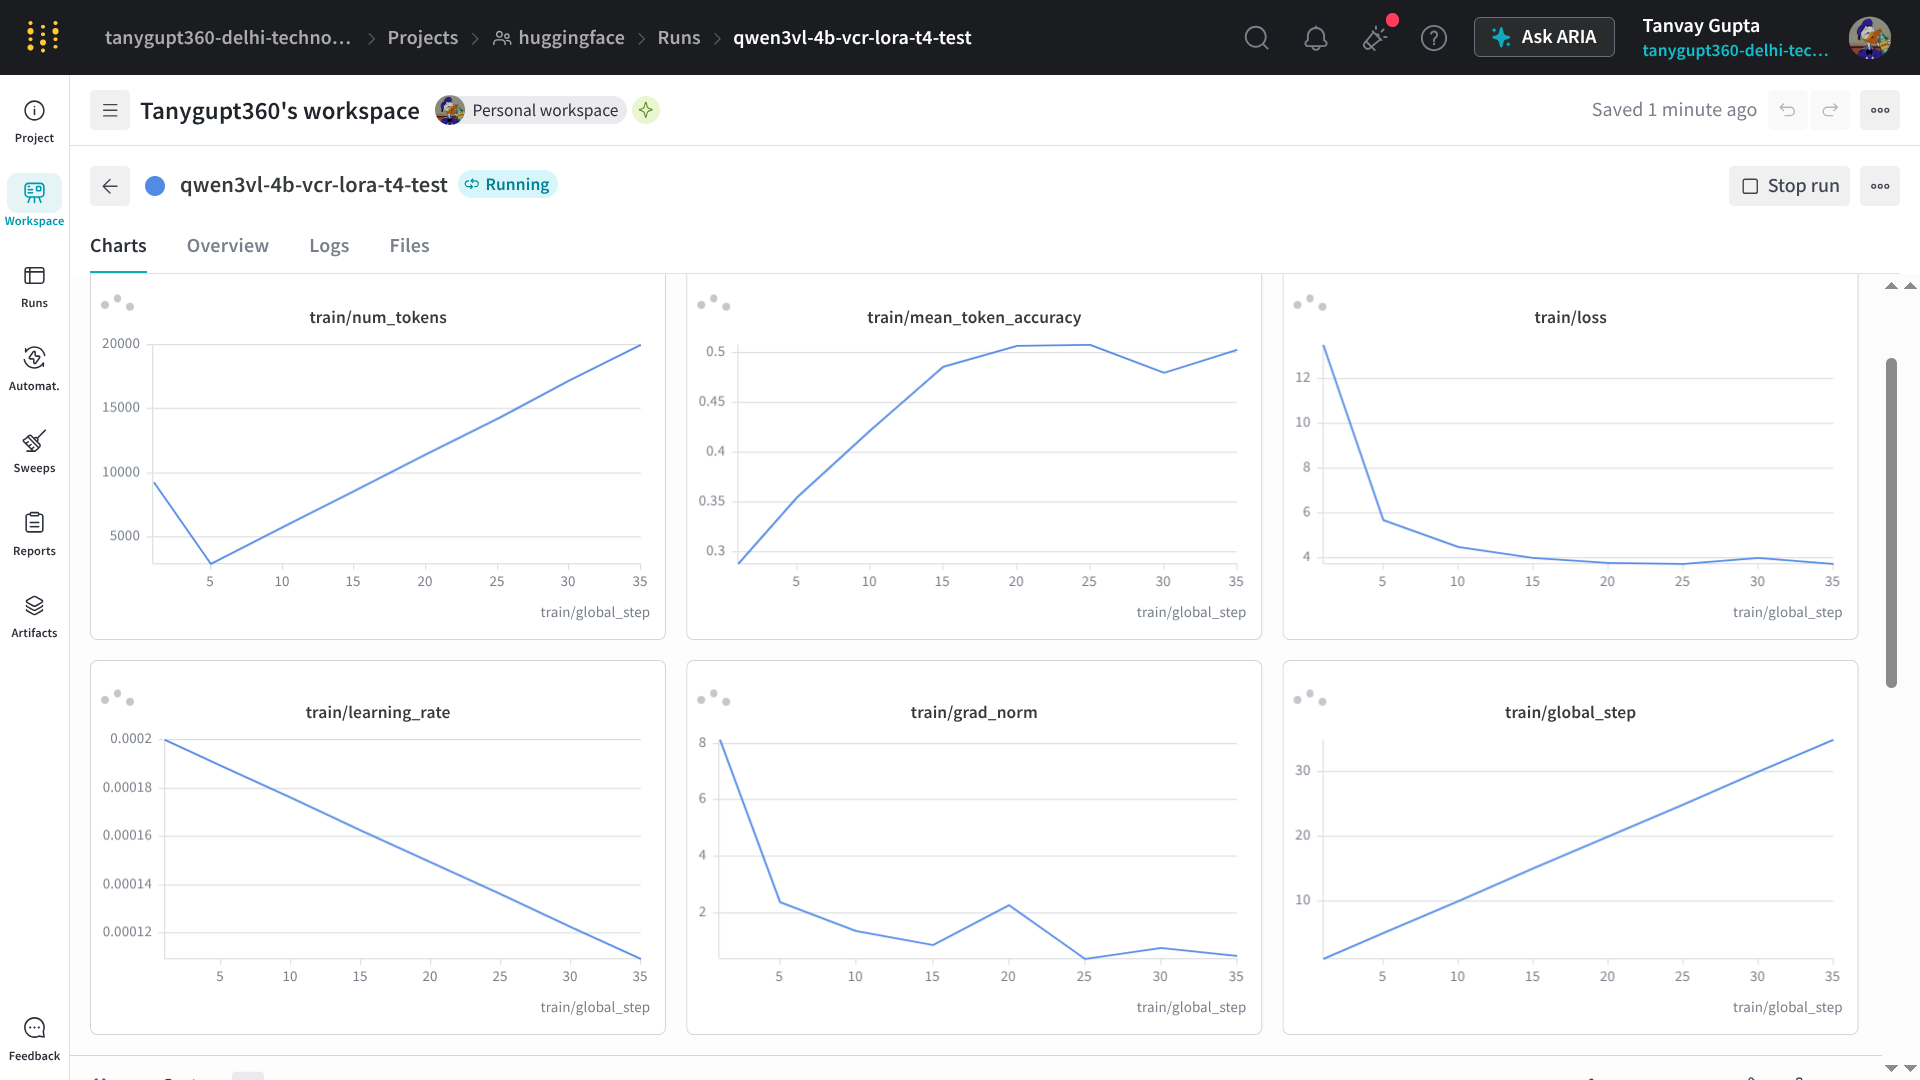

## DID YOU THINK IT ENDED?

FUCK NO, because now the model outputs a whole essay and I trained it for hours on the wrong thing.
I Now have 4 hours to train model and fix it

This is crazy, one missed line turns everything disastrous and apocalyptic lowk



# T - 3

I retrained it, and guess what, yes i retrained it on answers only because im me
but dw, i'll add rationales rq. The main time consuming step is the training part

For now, 56% Q -> A
28% Q -> R
and 16% Q -> AR

Its poopy lowk
My friend has greater than 60% accuracy and Q -> AR above 35%, and this pisses me off




# Check out RUN_THIS_v7. That's the final version for now
